In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

SRC_ROOT = Path.cwd()

while not (SRC_ROOT / "core").exists():
    if SRC_ROOT.parent == SRC_ROOT:
        raise RuntimeError("Cannot find src root")
    SRC_ROOT = SRC_ROOT.parent


PROJECT_ROOT = SRC_ROOT.parent


if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("SRC_ROOT     :", SRC_ROOT)
print("WORKING_DIR  :", Path.cwd())

# Load Evaluator
from fine_tuning.evaluator import E2EEvaluator

# Load Core Pipeline Agents
from models.query_parser import QueryParser
from models.retriever import DocumentRetriever
from models.reranker import DocumentReranker
from models.answer_generator import AnswerGenerator
from pipeline.rag_orchestrator import RAGOrchestrator

from core.retriever.pg_hybrid_retriever import PGHybridRetrieverModel

from core.llm.manager import LLMManager
from core.reranker.factory import RerankerFactory
from utils.config_loader import GLOBAL_CONFIG

PROJECT_ROOT : /home/huynh-gia-bao/Documents/NLP-assignment
SRC_ROOT     : /home/huynh-gia-bao/Documents/NLP-assignment/src
WORKING_DIR  : /home/huynh-gia-bao/Documents/NLP-assignment
2026-06-16 17:27:45 - [INFO] - utils.config_loader - Loaded config: retriever.yaml
2026-06-16 17:27:45 - [INFO] - utils.config_loader - Loaded config: models.yaml
2026-06-16 17:27:45 - [INFO] - utils.config_loader - Loaded config: prompts.yaml


/home/huynh-gia-bao/Documents/NLP-assignment/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
JUDGE_MODEL_PATH = "models/final_gguf/qwen3-4b-instruct-q4_k_m.gguf"
BENCHMARK_PATH = "data/benchmark/benchmark.jsonl"
llm_manager = LLMManager()

core_reranker = RerankerFactory.create_reranker(
    GLOBAL_CONFIG.get("models", {}).get("reranker", {})
)


query_parser = QueryParser(llm=llm_manager.parser_llm)
reranker_agent = DocumentReranker(reranker_model=core_reranker)
answer_generator=AnswerGenerator(llm=llm_manager.generator_llm)

2026-06-16 17:27:47 - [INFO] - core.llm.llama_cpp_model - Loading model from: models/final_gguf/qwen3-0.6b-instruct-q4_k_m.gguf
2026-06-16 17:27:47 - [INFO] - core.llm.llama_cpp_model - Using chat format: chatml


llama_context: n_ctx_seq (512) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


2026-06-16 17:27:47 - [INFO] - core.llm.llama_cpp_model - Model loaded successfully.
2026-06-16 17:27:47 - [INFO] - core.llm.llama_cpp_model - Loading model from: models/final_gguf/qwen3-4b-instruct-q4_k_m.gguf
2026-06-16 17:27:47 - [INFO] - core.llm.llama_cpp_model - Using chat format: chatml


llama_context: n_ctx_seq (4096) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


2026-06-16 17:27:48 - [INFO] - core.llm.llama_cpp_model - Model loaded successfully.
2026-06-16 17:27:48 - [INFO] - core.reranker.cross_encoder_reranker - Loading Cross-Encoder Reranker from: BAAI/bge-reranker-base


Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4218.46it/s]


2026-06-16 17:27:55 - [INFO] - core.reranker.cross_encoder_reranker - Cross-Encoder loaded successfully on CUDA.


In [3]:
base_db_config = {
    "type": "pg_hybrid",
    "embed_model_path": "BAAI/bge-small-en-v1.5",
    "lora_adapter_path": None, 
    "weights": {"semantic": 0.7, "keyword": 0.3},
    "database": {"host": "localhost", "port": 5432, "dbname": "rag_database", "user": "admin", "password": "secretpassword"}
}

base_retriever_model = PGHybridRetrieverModel(base_db_config)
base_doc_retriever = DocumentRetriever(retriever_model=base_retriever_model)

base_orchestrator = RAGOrchestrator(
    query_parser, base_doc_retriever, reranker_agent, answer_generator
)


lora_db_config = {
    "type": "pg_hybrid",
    "embed_model_path": "BAAI/bge-small-en-v1.5",
    "lora_adapter_path": "models/checkpoints/bge-lora-activation-guided/lora_adapter", 
    "weights": {"semantic": 0.7, "keyword": 0.3},
    "database": {"host": "localhost", "port": 5432, "dbname": "rag_database", "user": "admin", "password": "secretpassword"}
}

lora_retriever_model = PGHybridRetrieverModel(lora_db_config)
lora_doc_retriever = DocumentRetriever(retriever_model=lora_retriever_model)

# Đóng gói thành Orchestrator 2
lora_orchestrator = RAGOrchestrator(
    query_parser, lora_doc_retriever, reranker_agent, answer_generator
)

2026-06-16 17:27:55 - [INFO] - core.retriever.pg_hybrid_retriever - Loading local Embedding model from: BAAI/bge-small-en-v1.5


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 12762.48it/s]


2026-06-16 17:28:02 - [INFO] - core.retriever.pg_hybrid_retriever - Connecting to PostgreSQL Database at localhost:5432...
2026-06-16 17:28:02 - [INFO] - core.retriever.pg_hybrid_retriever - Database connection established successfully.
2026-06-16 17:28:02 - [INFO] - core.retriever.pg_hybrid_retriever - Loading local Embedding model from: BAAI/bge-small-en-v1.5


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 11042.90it/s]


2026-06-16 17:28:08 - [INFO] - core.retriever.pg_hybrid_retriever - Connecting to PostgreSQL Database at localhost:5432...
2026-06-16 17:28:08 - [INFO] - core.retriever.pg_hybrid_retriever - Database connection established successfully.


In [4]:
evaluator = E2EEvaluator(judge_model_path=JUDGE_MODEL_PATH)

print("Starting the evaluation between the Base Model and the LoRA Model...")
df_results = evaluator.evaluate_pipeline(
    base_orchestrator=base_orchestrator, 
    benchmark_path=BENCHMARK_PATH
)

df_results.to_csv("data/benchmark/e2e_evaluation_results.csv", index=False)
display(df_results.head())

[LLM-Judge] Đang tải Qwen-Judge từ: models/final_gguf/qwen3-4b-instruct-q4_k_m.gguf


llama_context: n_ctx_seq (2048) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


Starting the evaluation between the Base Model and the LoRA Model...
Đã tải 50 câu hỏi benchmark.


Đang chạy E2E Evaluation:   0%|                                                                                                                  | 0/50 [00:00<?, ?it/s]

2026-06-16 17:28:09 - [INFO] - pipeline.rag_orchestrator - ========== STARTING RAG PIPELINE ==========
2026-06-16 17:28:09 - [INFO] - pipeline.rag_orchestrator - User Query: 'How do I use the scipy.linalg.leslie function to create a Leslie matrix?'
2026-06-16 17:28:09 - [INFO] - pipeline.rag_orchestrator - [Step 1/4] Parsing Query...
2026-06-16 17:28:09 - [INFO] - models.query_parser - Parsing raw query: 'How do I use the scipy.linalg.leslie function to create a Leslie matrix?'
2026-06-16 17:28:13 - [WARNING] - models.query_parser - Failed to parse JSON. Fallback applied. Raw output: <think>
Okay, the user is asking how to create a Leslie matrix using the scipy.linalg.leslie function. Let me break this down.

First, I need to recall what the Leslie matrix is. From what I remember, the Leslie matrix is a symmetric matrix used in population genetics, specifically for modeling the reproduction of individuals in a population. It's often used in the context of the Leslie matrix for calculat

...

2026-06-16 17:51:41 - [INFO] - pipeline.rag_orchestrator - ========== STARTING RAG PIPELINE ==========
2026-06-16 17:51:41 - [INFO] - pipeline.rag_orchestrator - User Query: 'How do I use the seaborn.heatmap function to create a heatmap from a 2D dataset?'
2026-06-16 17:51:41 - [INFO] - pipeline.rag_orchestrator - [Step 1/4] Parsing Query...
2026-06-16 17:51:41 - [INFO] - models.query_parser - Parsing raw query: 'How do I use the seaborn.heatmap function to create a heatmap from a 2D dataset?'
2026-06-16 17:51:44 - [WARNING] - models.query_parser - Failed to parse JSON. Fallback applied. Raw output: <think>
Okay, the user is asking how to use the seaborn.heatmap function to create a heatmap from a 2D dataset. Let me break this down.

First, I need to check if there's a specific library mentioned. The user didn't mention any specific library like pandas or numpy, just "seaborn.heatmap". So, the library_name field should be empty or null here.

Next, the user wants to create a heatmap. T

Đang chạy E2E Evaluation:  98%|██████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 49/50 [24:00<00:30, 30.05s/it]

2026-06-16 17:52:09 - [INFO] - pipeline.rag_orchestrator - ========== STARTING RAG PIPELINE ==========
2026-06-16 17:52:09 - [INFO] - pipeline.rag_orchestrator - User Query: 'How can I use the transform function to apply a custom aggregation function to each column in a DataFrame?'
2026-06-16 17:52:09 - [INFO] - pipeline.rag_orchestrator - [Step 1/4] Parsing Query...
2026-06-16 17:52:09 - [INFO] - models.query_parser - Parsing raw query: 'How can I use the transform function to apply a custom aggregation function to each column in a DataFrame?'
2026-06-16 17:52:13 - [WARNING] - models.query_parser - Failed to parse JSON. Fallback applied. Raw output: <think>
Okay, the user is asking about using the transform function in Python to apply a custom aggregation function to each column in a DataFrame. Let me break this down.

First, I need to recall how the pandas DataFrame's transform method works. The transform method allows applying a function to each element in a DataFrame. But the user 

Đang chạy E2E Evaluation: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [24:30<00:00, 29.41s/it]


,query,base_score,base_latency
0,How do I use the scipy.linalg.leslie function ...,3,27.575892
1,How can I use the scipy.stats.rv_histogram fun...,3,26.254875
2,How can I use the pandas.Series.rsub function ...,3,26.436891
3,How can I use the `set_params` method to updat...,3,21.314264
4,How can I convert a pandas Series to an xarray...,3,25.165783


--- AVERAGE E2E EVALUATION RESULTS (BASE ONLY) ---
LLM Judge Quality Score: Base = 2.94/5.0
Response Time (Latency): Base = 25.39s


/tmp/ipykernel_377665/2563064236.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_377665/2563064236.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


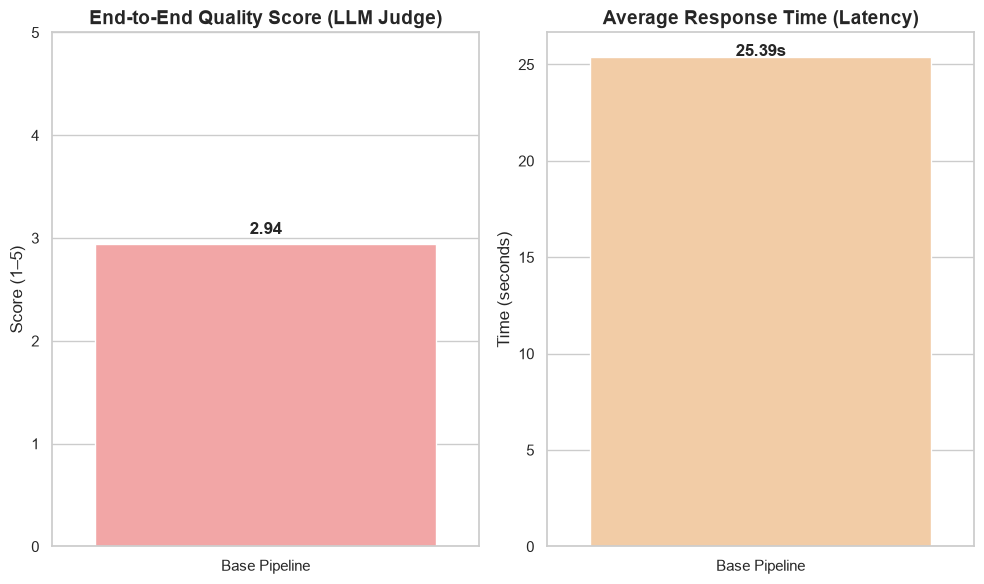

In [9]:
# Cài đặt thư viện vẽ đồ thị nếu chưa có (chạy 1 lần)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán giá trị trung bình (Chỉ dành cho Base)
mean_base_score = df_results['base_score'].mean()
mean_base_latency = df_results['base_latency'].mean()

print("--- AVERAGE E2E EVALUATION RESULTS (BASE ONLY) ---")
print(f"LLM Judge Quality Score: Base = {mean_base_score:.2f}/5.0")
print(f"Response Time (Latency): Base = {mean_base_latency:.2f}s")

# 2. Cấu hình giao diện đồ thị
sns.set_theme(style="whitegrid")
# Thu nhỏ lại kích thước một chút (10, 6) vì bây giờ chỉ vẽ 1 cột mỗi bên
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# --- Đồ thị 1: Điểm Chất Lượng (Quality Score) ---
sns.barplot(
    x=['Base Pipeline'],
    y=[mean_base_score],
    palette=['#ff9999'], # Màu cam/hồng nhạt
    ax=axes[0]
)
axes[0].set_title(
    'End-to-End Quality Score (LLM Judge)',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_ylabel('Score (1–5)', fontsize=12)
axes[0].set_ylim(0, 5) # Cố định trục Y từ 0 đến 5 điểm

# Thêm nhãn số liệu trực tiếp lên cột
axes[0].text(
    0, mean_base_score + 0.1, f"{mean_base_score:.2f}",
    ha='center',
    fontweight='bold',
    fontsize=12
)

# --- Đồ thị 2: Độ Trễ (Latency) ---
sns.barplot(
    x=['Base Pipeline'],
    y=[mean_base_latency],
    palette=['#ffcc99'], # Màu vàng/cam nhạt
    ax=axes[1]
)
axes[1].set_title(
    'Average Response Time (Latency)',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_ylabel('Time (seconds)', fontsize=12)

# Thêm nhãn số liệu (kèm chữ 's' cho giây)
axes[1].text(
    0, mean_base_latency + 0.05, f"{mean_base_latency:.2f}s",
    ha='center',
    fontweight='bold',
    fontsize=12
)

# Canh chỉnh và lưu đồ thị
plt.tight_layout()
# Đổi tên file ảnh lại cho phù hợp vì không còn so sánh nữa
plt.savefig("data/benchmark/e2e_evaluation_base.png") 
plt.show()